## Machine learning final project

## Predicting maternal risk during pregnancy

Teammates
- Emiliano Gallardo - ETU0250385
- Rodrigo Rivas - ETU20250600
- Laura Victoria Miquel - ETU20250311
- Luis Felipe Navarro - ETU20242106
- Janna Freund - 20250782
- Jacobo Ceballos Moná - ETU20242062



In [2]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot  as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



In [3]:
# read the data
df = pd.read_csv('Maternal Health Risk Data Set.csv')
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [4]:
# statistics from the data
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [7]:
# info from the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [8]:
# posible target values
df['RiskLevel'].unique()

array(['high risk', 'low risk', 'mid risk'], dtype=object)

In [10]:
# Function to the autocleaning process

dataframe = df

def clean_process(dataframe, threshold=0.33):
    df = df.dropna(how='all')   # Drop rows with all NaN
    df = df.drop_duplicates()   # Drop duplicate rows
    df = df.loc[:, df.isnull().sum() <= threshold*len(df)]   # Drop columns with more than threshold% NaN

    qualitative_cols = df.select_dtypes(include=['object']).columns
    for col in qualitative_cols:    # Fill NaN with the mode for qualitative values
        mode = df[col].mode()[0]
        df[col] = df[col].fillna(mode)

    quantitative_cols = df.select_dtypes(include=['number']).columns
    for col in quantitative_cols:   # Fill NaN with the mean for quantitative values
        mean = df[col].mean()
        df[col] = df[col].fillna(mean)

    return df

print(f'The dataset now contains {df.isnull().sum().sum()} null values.') # Display the sum of nulls
print(f'The columns contain the folowing number of null values:\n{df.isnull().sum()}')

The dataset now contains 0 null values.
The columns contain the folowing number of null values:
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64


In [ ]:
 df.isnull().sum()


,0
Age,0
SystolicBP,0
DiastolicBP,0
BS,0
BodyTemp,0
HeartRate,0
RiskLevel,0


/tmp/ipython-input-548462076.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='RiskLevel', data=df, palette='viridis')


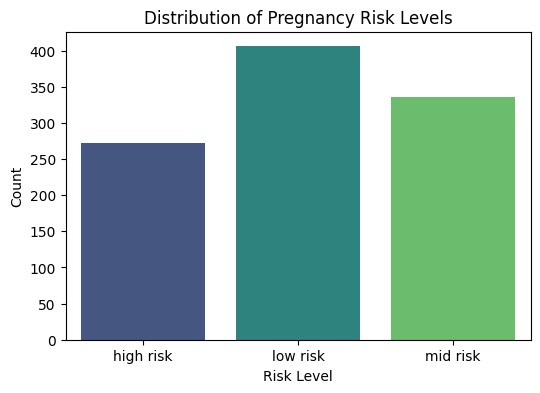

RiskLevel
low risk     40.039448
mid risk     33.136095
high risk    26.824458
Name: proportion, dtype: float64


In [11]:
# distribution of pregnancy risk
plt.figure(figsize=(6,4))
sns.countplot(x='RiskLevel', data=df, palette='viridis')
plt.title('Distribution of Pregnancy Risk Levels')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.show()

# Percentage per class
print(df['RiskLevel'].value_counts(normalize=True) * 100)

# Result --> The risk variables are well distributed among the three classes.

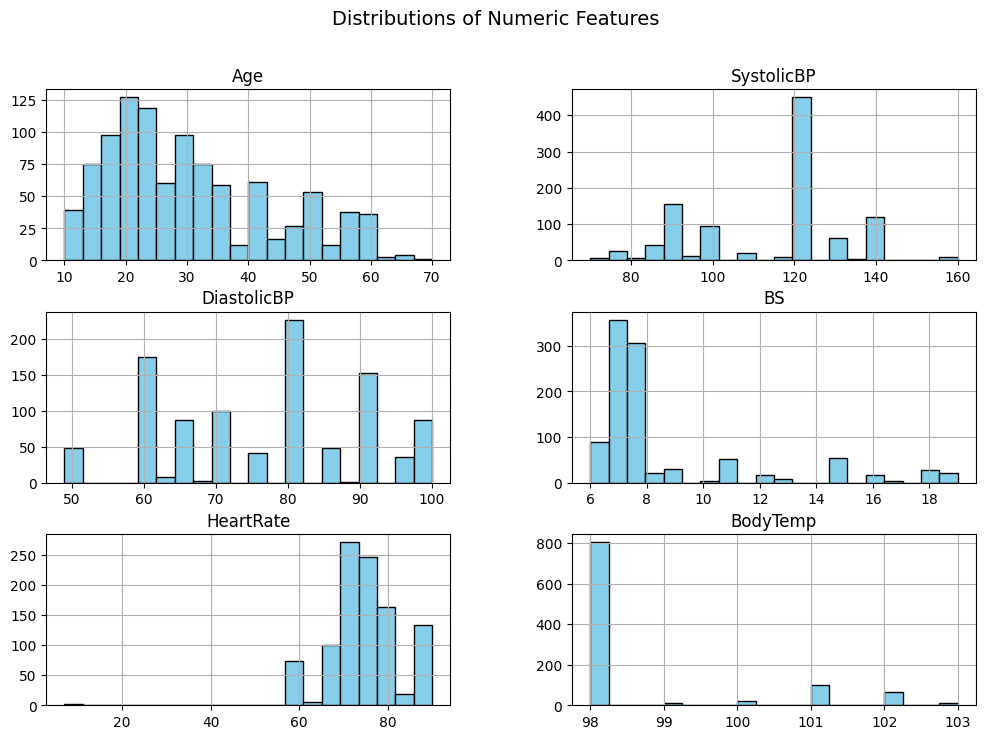

In [17]:
# distributions of other numeric features
numeric_cols = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'HeartRate', 'BodyTemp']

df[numeric_cols].hist(bins=20, figsize=(12,8), color='skyblue', edgecolor='black')
plt.suptitle('Distributions of Numeric Features', fontsize=14)
plt.show()


/tmp/ipython-input-1841280852.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RiskLevel', y=col, data=df, palette='coolwarm')


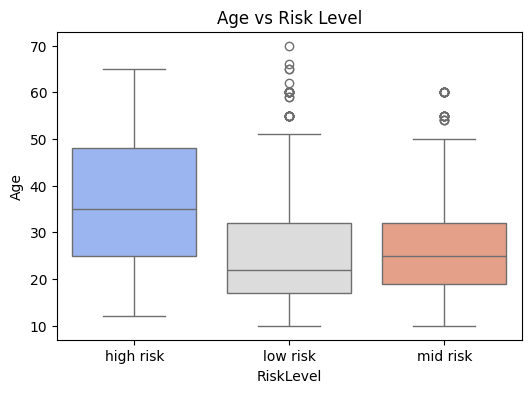

/tmp/ipython-input-1841280852.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RiskLevel', y=col, data=df, palette='coolwarm')


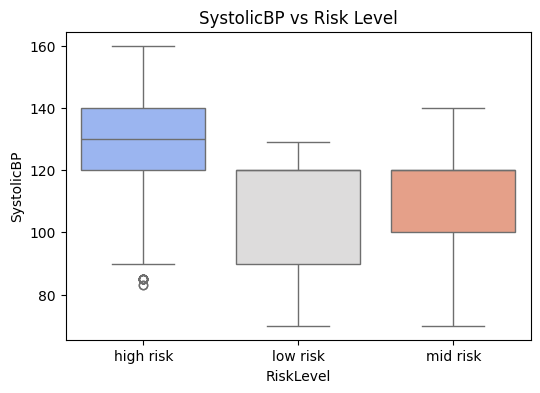

/tmp/ipython-input-1841280852.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RiskLevel', y=col, data=df, palette='coolwarm')


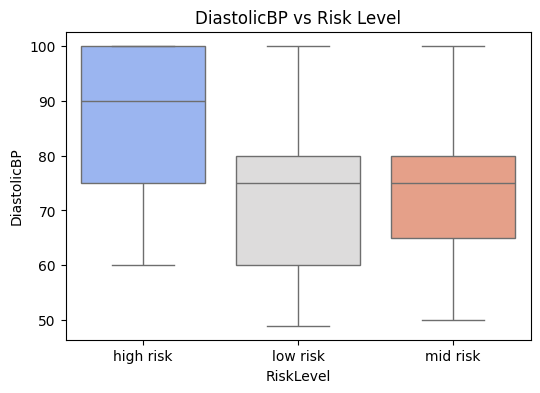

/tmp/ipython-input-1841280852.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RiskLevel', y=col, data=df, palette='coolwarm')


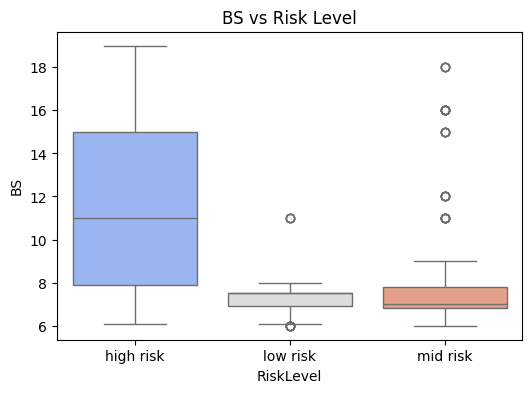

/tmp/ipython-input-1841280852.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RiskLevel', y=col, data=df, palette='coolwarm')


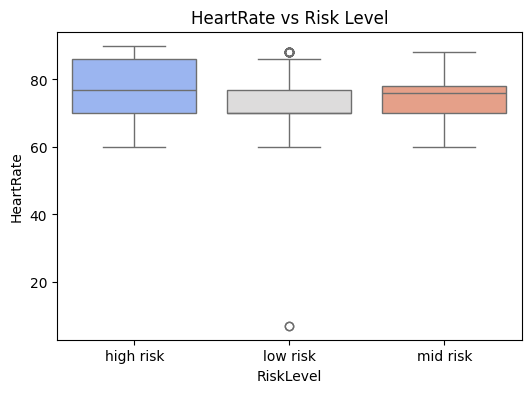

/tmp/ipython-input-1841280852.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RiskLevel', y=col, data=df, palette='coolwarm')


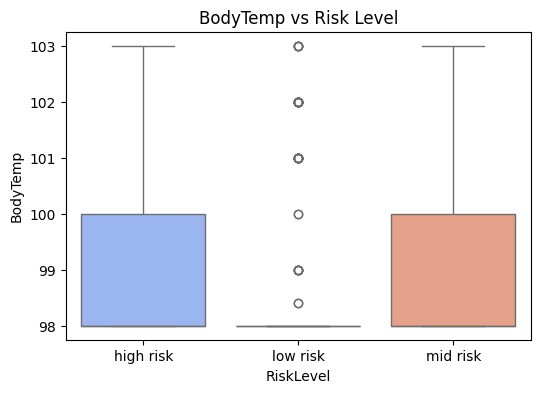

In [15]:
# boxplot of features vs risk level (target)
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='RiskLevel', y=col, data=df, palette='coolwarm')
    plt.title(f'{col} vs Risk Level')
    plt.show()

# Results --> How each vital sign changes across risk categories

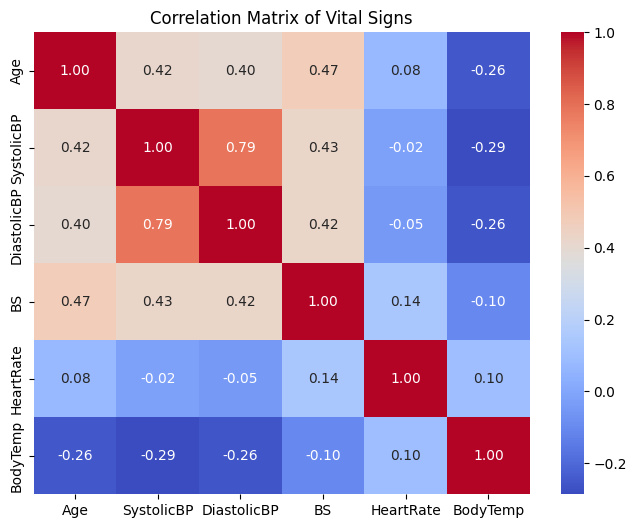

In [14]:
# correlation matrix between features
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Vital Signs')
plt.show()

In [19]:
# remove outliers
# Compute z-scores for each numeric column
z_scores = np.abs(stats.zscore(df[numeric_cols]))

# Create a boolean mask where True means "no outlier"
mask = (z_scores < 3).all(axis=1)

# Filter the dataframe
df_clean = df[mask].copy()

print("Original shape:", df.shape)
print("New shape after removing outliers:", df_clean.shape)
print(f"Removed {df.shape[0] - df_clean.shape[0]} rows as outliers.")


Original shape: (1014, 7)
New shape after removing outliers: (977, 7)
Removed 37 rows as outliers.


In [20]:
print("EDA Summary:")
print(f"- Dataset shape: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")
print(f"- RiskLevel distribution:\n{df_clean['RiskLevel'].value_counts()}")
print(f"- Highest correlation: {corr.unstack().sort_values(ascending=False)[5:10]}")


EDA Summary:
- Dataset shape: 977 rows, 7 columns
- RiskLevel distribution:
RiskLevel
low risk     399
mid risk     334
high risk    244
Name: count, dtype: int64
- Highest correlation: BS           BS             1.000000
SystolicBP   DiastolicBP    0.787006
DiastolicBP  SystolicBP     0.787006
Age          BS             0.473284
BS           Age            0.473284
dtype: float64


In [21]:
# Encode RiskLevel
# Map categorical risk levels to numeric labels
label_map = {'low risk': 0, 'mid risk': 1, 'high risk': 2}

df_clean['RiskLabel'] = df_clean['RiskLevel'].map(label_map)

# Check the mapping result
print(df_clean[['RiskLevel', 'RiskLabel']].head())
print("\nEncoded risk level distribution:")
print(df_clean['RiskLabel'].value_counts())

   RiskLevel  RiskLabel
0  high risk          2
1  high risk          2
2  high risk          2
3  high risk          2
4   low risk          0

Encoded risk level distribution:
RiskLabel
0    399
1    334
2    244
Name: count, dtype: int64


In [22]:
# scale the data
scaler = StandardScaler()
df_scaled = df_clean.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])
df_scaled.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,RiskLabel
0,-0.347082,0.979577,0.282421,2.186805,-0.480177,1.525803,high risk,2
1,0.404634,1.544307,1.011610,1.512141,-0.480177,-0.582884,high risk,2
2,-0.046396,-1.279340,-0.446768,-0.174518,1.059479,0.735046,high risk,2
3,0.028776,1.544307,0.647016,-0.511850,-0.480177,-0.582884,high risk,2
4,0.404634,0.414848,-1.175958,-0.815449,-0.480177,0.207874,low risk,0


In [23]:
# Define features (X) and target (y)
X = df_scaled[['Age', 'SystolicBP', 'DiastolicBP', 'BS',  'BodyTemp', 'HeartRate']]
y = df_scaled['RiskLabel']

In [24]:
# split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)

In [25]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [34]:
print("\nRandom Forest Results:")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))



Random Forest Results:
              precision    recall  f1-score   support

           0       0.92      0.82      0.86       120
           1       0.80      0.82      0.81       101
           2       0.82      0.93      0.87        73

    accuracy                           0.85       294
   macro avg       0.84      0.86      0.85       294
weighted avg       0.85      0.85      0.85       294

Accuracy: 0.8469387755102041

Confusion Matrix:
 [[98 17  5]
 [ 8 83 10]
 [ 1  4 68]]


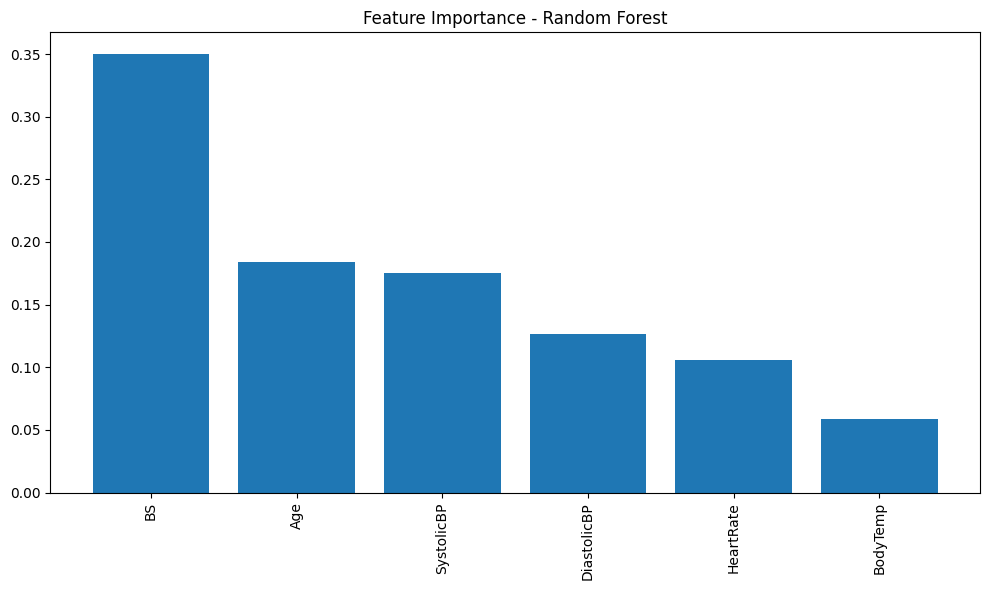

In [33]:
# Get feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot top features
plt.figure(figsize=(10,6))
plt.title("Feature Importance - Random Forest")
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.tight_layout()
plt.show()


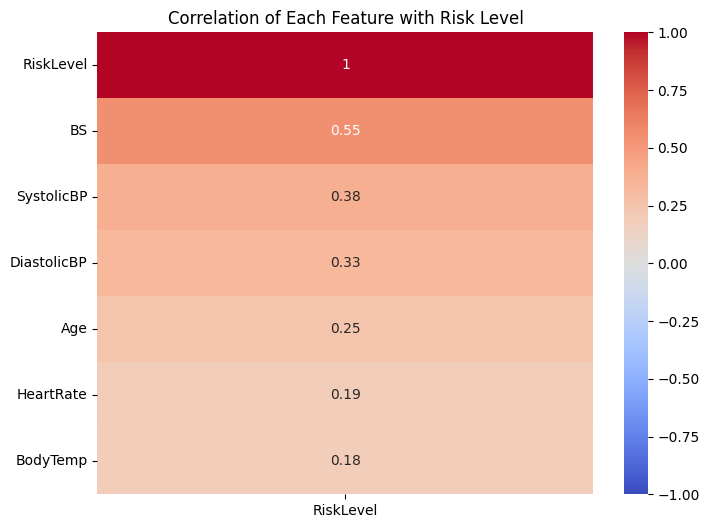

In [45]:
# Combine X and y into one dataframe
df_corr = X.copy()
df_corr['RiskLevel'] = y

# Compute correlation matrix
corr = df_corr.corr()

# Visualize correlations with RiskLevel
plt.figure(figsize=(8,6))
sns.heatmap(corr[['RiskLevel']].sort_values(by='RiskLevel', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Each Feature with Risk Level')
plt.show()


In [55]:
# Thresholds for each feature
# List of features to analyze
features = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']

# Define nice units for labels
units = {
    'Age': 'years',
    'SystolicBP': 'mmHg',
    'DiastolicBP': 'mmHg',
    'BS': 'mmol/L',
    'BodyTemp': '°C',
    'HeartRate': 'bpm'
}

# Loop through each feature and plot
for col in features:
    '''plt.figure(figsize=(8,5))
    sns.boxplot(x=y, y=df_scaled[col], palette='viridis')
    plt.title(f'{col} Distribution Across Risk Levels')    plt.xlabel('Risk Level (0 = Low, 1 = Mid, 2 = High)')
    plt.ylabel(f'{col} ({units.get(col, "")})')
    plt.show()'''

    # Compute rough threshold: median value in the High-Risk group
    threshold = df_clean.loc[y == 2, col].median()

    # Print simple interpretation
    print(f"Possible threshold: {col} > {threshold:.2f} {units.get(col, '')} → higher risk\n")


Possible threshold: Age > 35.00 years → higher risk

Possible threshold: SystolicBP > 120.00 mmHg → higher risk

Possible threshold: DiastolicBP > 90.00 mmHg → higher risk

Possible threshold: BS > 11.00 mmol/L → higher risk

Possible threshold: BodyTemp > 98.00 °C → higher risk

Possible threshold: HeartRate > 78.00 bpm → higher risk



In [47]:
#Training the model with our most important features
# Define features (X) and target (y)
X2 = df_scaled[['Age', 'SystolicBP', 'DiastolicBP', 'BS']]
y2 = df_scaled['RiskLabel']

In [48]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.3, stratify=y2, random_state=42)

In [49]:
#Applying PCA
from sklearn.decomposition import PCA
apply_pca = True  # Cambia a True si quieres probar PCA
if apply_pca:
    pca = PCA(n_components=0.95)
    X2_train = pca.fit_transform(X2_train)
    X2_test = pca.transform(X2_test)
    print("Retained components:", pca.n_components_)


Retained components: 4


In [52]:
# Random Forest
rf2 = RandomForestClassifier(n_estimators=100, random_state=40)
rf2.fit(X2_train, y2_train)
y2_pred_rf = rf2.predict(X2_test)

In [51]:
print("\nRandom Forest Results:")
print(classification_report(y2_test, y2_pred_rf))
print("Accuracy:", accuracy_score(y2_test, y2_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y2_test, y2_pred_rf))


Random Forest Results:
              precision    recall  f1-score   support

           0       0.85      0.79      0.82       120
           1       0.76      0.77      0.76       101
           2       0.85      0.92      0.88        73

    accuracy                           0.82       294
   macro avg       0.82      0.83      0.82       294
weighted avg       0.82      0.82      0.82       294

Accuracy: 0.8163265306122449

Confusion Matrix:
 [[95 21  4]
 [15 78  8]
 [ 2  4 67]]
